In [1]:
# If needed, install:
# !pip install SimpleITK ipywidgets matplotlib

%matplotlib inline

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from ipywidgets import interact, IntSlider


In [2]:
# --- INPUTS ---
input_path = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\mamo\cmmd_d2_0749"
# force_modality = "US"   # for echocardiography
force_modality = "MG"   # for mammography

# input_path = r"C:\path\to\mammography_series_folder"  # alternative: a directory

# Where to save NRRD outputs for VolView
# output_dir = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\processed"
output_dir = r"C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\processed_mamo"
Path(output_dir).mkdir(parents=True, exist_ok=True)

# --- PIPELINE PARAMETERS ---

# Mammography - Background-aware processing with zero background
mg_params_zero_bg = dict(
    denoise=dict(
        enabled=True,
        method="median",        # "median" or "gaussian"
        median_radius=(2, 2)    # small radius to avoid harming microcalcifications
    ),
    contrast=dict(
        enabled=True,
        method="percentile_stretch",         # "clahe", "gentle_gamma", or "percentile_stretch"
        clahe_radius=(32, 32),  # Increased radius for gentler local enhancement
        alpha=0.3,              # Higher alpha for more conservative enhancement
        beta=0.05,              # Much lower beta for subtle clipping
        stretch_low=0.5,        # percentiles for global stretch
        stretch_high=99.5,
        gamma=0.8               # for gentle_gamma method
    ),
    sharpen=dict(
        enabled=True,
        sigma=0.5,              # slightly smaller sigma for high-res MG
        amount=1.2,
        threshold=0.0
    ),
    normalize=dict(
        enabled=True,
        method="rescale_uint8",
        perc_low=0.5,
        perc_high=99.5
    )
)

# Mammography - FIXED CLAHE parameters for subtle enhancement (original version)
mg_params = dict(
    denoise=dict(
        enabled=True,
        method="median",        # "median" or "gaussian"
        median_radius=(1, 1)    # small radius to avoid harming microcalcifications
    ),
    contrast=dict(
        enabled=True,
        method="clahe",         # "clahe" or "percentile_stretch"
        clahe_radius=(16, 16),  # Increased radius for gentler local enhancement
        alpha=0.3,              # Higher alpha for more conservative enhancement
        beta=0.05,              # Much lower beta for subtle clipping (was 0.2)
        stretch_low=1.0,        # percentiles for global stretch
        stretch_high=99.0
    ),
    sharpen=dict(
        enabled=True,
        sigma=0.5,              # slightly smaller sigma for high-res MG
        amount=1.2,
        threshold=0.0
    ),
    normalize=dict(
        enabled=True,
        method="rescale_uint8",
        perc_low=0.5,
        perc_high=99.5
    )
)

In [3]:
# === ALTERNATIVE PARAMETER CONFIGURATIONS ===
# Uncomment and use these if the default parameters are still too aggressive

# VERY GENTLE Mammography processing (minimal changes)
mg_params_gentle = dict(
    denoise=dict(
        enabled=True,
        method="median",        
        median_radius=(1, 1)    
    ),
    contrast=dict(
        enabled=True,
        method="gentle_gamma",  # Use gentle gamma instead of CLAHE
        gamma=0.9,              # Very subtle gamma correction (closer to 1.0)
        # Alternative CLAHE settings if you prefer:
        # method="clahe",         
        # clahe_radius=(32, 32),  # Very large radius for minimal local enhancement
        # alpha=0.8,              # Very conservative enhancement
        # beta=0.01,              # Minimal contrast limiting
    ),
    sharpen=dict(
        enabled=True,
        sigma=0.8,              # Slightly larger sigma for gentler sharpening
        amount=0.8,             # Reduced sharpening amount
        threshold=0.0
    ),
    normalize=dict(
        enabled=True,
        method="rescale_uint8",
        perc_low=1.0,           # More conservative percentile clipping
        perc_high=99.0
    )
)

# PERCENTILE-BASED Mammography processing (alternative to CLAHE)
mg_params_percentile = dict(
    denoise=dict(
        enabled=True,
        method="median",        
        median_radius=(1, 1)    
    ),
    contrast=dict(
        enabled=True,
        method="percentile_stretch",  # Use percentile stretching instead of CLAHE
        stretch_low=5.0,              # Gentle percentile stretch
        stretch_high=95.0
    ),
    sharpen=dict(
        enabled=True,
        sigma=0.5,              
        amount=1.0,             # Moderate sharpening
        threshold=0.0
    ),
    normalize=dict(
        enabled=True,
        method="rescale_uint8",
        perc_low=0.5,
        perc_high=99.5
    )
)

print("Available parameter sets:")
print("1. mg_params - Conservative CLAHE (current)")
print("2. mg_params_gentle - Very gentle gamma correction")
print("3. mg_params_percentile - Percentile-based contrast stretch")
print("\nTo use alternative parameters, replace 'mg_params' with one of the above in the pipeline call.")
print("Current parameters being used: mg_params")

Available parameter sets:
1. mg_params - Conservative CLAHE (current)
2. mg_params_gentle - Very gentle gamma correction
3. mg_params_percentile - Percentile-based contrast stretch

To use alternative parameters, replace 'mg_params' with one of the above in the pipeline call.
Current parameters being used: mg_params


In [4]:
def save_nrrd(img: sitk.Image, filepath: str) -> str:
    """Save SimpleITK image as NRRD file and return the filepath."""
    sitk.WriteImage(img, filepath)
    return filepath

def to_scalar_float(img: sitk.Image) -> sitk.Image:
    """Return a scalar (grayscale) float32 image with same spatial meta as input.
       If the image is already scalar, just cast to float32.
       If RGB (3 comps), use ITU-R 601 luma weights; otherwise use vector magnitude.
    """
    if img.GetNumberOfComponentsPerPixel() == 1:
        out = sitk.Cast(img, sitk.sitkFloat32)
    else:
        comps = img.GetNumberOfComponentsPerPixel()
        if comps == 3:
            r = sitk.Cast(sitk.VectorIndexSelectionCast(img, 0), sitk.sitkFloat32)
            g = sitk.Cast(sitk.VectorIndexSelectionCast(img, 1), sitk.sitkFloat32)
            b = sitk.Cast(sitk.VectorIndexSelectionCast(img, 2), sitk.sitkFloat32)
            out = 0.299*r + 0.587*g + 0.114*b
        else:
            out = sitk.Cast(sitk.VectorMagnitude(img), sitk.sitkFloat32)
    out.CopyInformation(img)
    return out

def create_background_mask_ultrafast(img: sitk.Image, threshold_percentile: float = 5.0) -> sitk.Image:
    """Create a background mask using ultra-fast percentile thresholding without morphological operations.
    
    Args:
        img: Input SimpleITK image
        threshold_percentile: Percentile to use for threshold (default: 5.0 for more conservative)
    
    Returns:
        Binary mask where 1 = foreground (tissue), 0 = background
    """
    img_float = to_scalar_float(img)
    arr = sitk.GetArrayFromImage(img_float)
    
    # Use a more conservative percentile-based threshold
    # For mammography, background is typically very dark
    threshold = np.percentile(arr, threshold_percentile)

    threshold = 1.0
    # Create binary mask using SimpleITK - just threshold, no morphology
    mask = sitk.BinaryThreshold(img_float, threshold, float('inf'), 1, 0)
    
    return mask

def minmax_normalize_with_background(img: sitk.Image, mask: sitk.Image = None, 
                                   out_min: float = 0.0, out_max: float = 1.0, 
                                   background_value: float = 0.0) -> sitk.Image:
    """Apply min-max normalization with background preservation.
    
    Args:
        img: Input SimpleITK image
        mask: Optional foreground mask (1=foreground, 0=background)
        out_min: Minimum value of output range for foreground (default: 0.0)
        out_max: Maximum value of output range for foreground (default: 1.0)
        background_value: Value to assign to background pixels (default: 0.0)
    
    Returns:
        Normalized SimpleITK image with background set to background_value
    """
    img_float = to_scalar_float(img)
    arr = sitk.GetArrayFromImage(img_float)
    
    if mask is None:
        # Create automatic background mask using ultra-fast method
        mask = create_background_mask_ultrafast(img_float)
    
    mask_arr = sitk.GetArrayFromImage(mask).astype(bool)
    
    # Get foreground pixels only
    foreground_pixels = arr[mask_arr]
    
    if len(foreground_pixels) == 0:
        # No foreground found, return original image
        return img_float
    
    # Calculate min/max from foreground only
    fg_min, fg_max = foreground_pixels.min(), foreground_pixels.max()
    
    # Initialize output array with background value
    arr_normalized = np.full_like(arr, background_value, dtype=np.float32)
    
    # Normalize foreground pixels only
    if fg_max > fg_min:
        arr_normalized[mask_arr] = (foreground_pixels - fg_min) / (fg_max - fg_min) * (out_max - out_min) + out_min
    else:
        arr_normalized[mask_arr] = out_min
    
    result = sitk.GetImageFromArray(arr_normalized)
    result.CopyInformation(img_float)
    return result

def mg_contrast_clahe_with_background(img: sitk.Image, mask: sitk.Image = None,
                                    alpha: float = 0.3, beta: float = 0.05, 
                                    radius: tuple = (16, 16)) -> sitk.Image:
    """Apply CLAHE only to foreground regions, preserving background as zero.
    
    Args:
        img: Input SimpleITK image
        mask: Optional foreground mask (1=foreground, 0=background)
        alpha, beta, radius: CLAHE parameters
    
    Returns:
        CLAHE-enhanced image with background preserved as zero
    """
    img_float = to_scalar_float(img)
    
    if mask is None:
        # Create automatic background mask using ultra-fast method
        mask = create_background_mask_ultrafast(img_float)
    
    # Apply CLAHE only to foreground
    arr = sitk.GetArrayFromImage(img_float)
    mask_arr = sitk.GetArrayFromImage(mask).astype(bool)
    
    # Create a temporary image with only foreground for CLAHE processing
    # Set background to mean of foreground to avoid CLAHE artifacts at boundaries
    fg_pixels = arr[mask_arr]
    if len(fg_pixels) > 0:
        fg_mean = fg_pixels.mean()
        temp_arr = arr.copy()
        temp_arr[~mask_arr] = fg_mean
        
        temp_img = sitk.GetImageFromArray(temp_arr.astype(np.float32))
        temp_img.CopyInformation(img_float)
        
        # Apply CLAHE to the temporary image
        clahe_result = mg_contrast_clahe(temp_img, alpha, beta, radius)
        clahe_arr = sitk.GetArrayFromImage(clahe_result)
        
        # Create output: use CLAHE result for foreground, zero for background
        result_arr = np.zeros_like(arr, dtype=np.float32)
        result_arr[mask_arr] = clahe_arr[mask_arr]
    else:
        result_arr = np.zeros_like(arr, dtype=np.float32)
    
    result = sitk.GetImageFromArray(result_arr)
    result.CopyInformation(img_float)
    return result

def minmax_normalize(img: sitk.Image, out_min: float = 0.0, out_max: float = 1.0) -> sitk.Image:
    """Apply min-max normalization to scale image intensities to a specified range.
    
    Args:
        img: Input SimpleITK image
        out_min: Minimum value of output range (default: 0.0)
        out_max: Maximum value of output range (default: 1.0)
    
    Returns:
        Normalized SimpleITK image with intensities in [out_min, out_max] range
    """
    img_float = to_scalar_float(img)
    arr = sitk.GetArrayFromImage(img_float)
    
    # Get min and max values
    arr_min, arr_max = arr.min(), arr.max()
    
    # Avoid division by zero
    if arr_max <= arr_min:
        # If all values are the same, return image filled with out_min
        arr_normalized = np.full_like(arr, out_min)
    else:
        # Apply min-max normalization: (x - min) / (max - min) * (out_max - out_min) + out_min
        arr_normalized = (arr - arr_min) / (arr_max - arr_min) * (out_max - out_min) + out_min
    
    result = sitk.GetImageFromArray(arr_normalized.astype(np.float32))
    result.CopyInformation(img_float)
    return result

def rescale_percentile(img: sitk.Image, p_low: float = 5.0, p_high: float = 99.5, 
                      out_min: float = 0.0, out_max: float = 255.0) -> sitk.Image:
    """Rescale image intensity using percentile stretching."""
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    lo, hi = np.percentile(arr, [p_low, p_high])
    if hi <= lo:
        lo, hi = float(arr.min()), float(arr.max())
        if hi <= lo:
            return img
    
    scaled = np.clip((arr - lo) / (hi - lo), 0, 1) * (out_max - out_min) + out_min
    out = sitk.GetImageFromArray(scaled.astype(np.float32))
    out.CopyInformation(img)
    return out

def mg_contrast_gentle_gamma(img: sitk.Image, gamma: float = 0.8) -> sitk.Image:
    """Apply gentle gamma correction for mammography (alternative to aggressive CLAHE)."""
    img_float = to_scalar_float(img)
    
    # Normalize to 0-1 range
    arr = sitk.GetArrayFromImage(img_float)
    arr_min, arr_max = arr.min(), arr.max()
    if arr_max > arr_min:
        arr_norm = (arr - arr_min) / (arr_max - arr_min)
        
        # Apply gamma correction
        arr_gamma = np.power(arr_norm, gamma)
        
        # Scale back to original range
        arr_scaled = arr_gamma * (arr_max - arr_min) + arr_min
    else:
        arr_scaled = arr
    
    result = sitk.GetImageFromArray(arr_scaled.astype(np.float32))
    result.CopyInformation(img_float)
    return result

def mg_contrast_clahe(img: sitk.Image, alpha: float = 0.3, beta: float = 0.05, 
                     radius: tuple = (16, 16)) -> sitk.Image:
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) for mammography.
    
    For mammography, we use more conservative parameters:
    - Higher alpha (0.3 instead of 0.0) for more conservative enhancement
    - Lower beta (0.05 instead of 0.2) for subtle contrast limiting
    - Larger radius (16,16 instead of 8,8) for gentler local adaptation
    """
    # Convert to float32 first
    img_float = to_scalar_float(img)
    
    # Ensure radius matches image dimension
    r = list(radius)
    if img_float.GetDimension() == 3 and len(r) == 2:
        r.append(0)  # Add Z dimension with 0 radius for 2D processing
    elif img_float.GetDimension() == 2 and len(r) == 3:
        r = r[:2]    # Remove Z dimension for 2D images
    
    # Apply CLAHE using SimpleITK's AdaptiveHistogramEqualization
    clahe = sitk.AdaptiveHistogramEqualizationImageFilter()
    clahe.SetAlpha(alpha)
    clahe.SetBeta(beta)
    clahe.SetRadius(tuple(r))
    
    result = clahe.Execute(img_float)
    return result

def mg_unsharp(img: sitk.Image, sigma: float = 0.5, amount: float = 1.2, 
               threshold: float = 0.0) -> sitk.Image:
    """Apply unsharp masking for mammography."""
    img_float = to_scalar_float(img)
    
    # Create Gaussian blurred version
    blurred = sitk.DiscreteGaussian(img_float, variance=sigma*sigma)
    
    # Create unsharp mask
    mask = img_float - blurred
    
    # Apply threshold if specified
    if threshold > 0:
        mask = sitk.Threshold(mask, -threshold, threshold, 0.0)
    
    # Apply unsharp masking
    result = img_float + amount * mask
    return result



In [5]:
def read_dicom_any(path: str, combine_series: bool = True) -> sitk.Image:
    """
    Read DICOM images from a path.
    
    Args:
        path: Path to DICOM file or directory containing DICOM series
        combine_series: If True and multiple series found, combine them into a single volume.
                       If False, only read the first series found.
    
    Returns:
        SimpleITK Image
    """
    p = Path(path)
    if p.is_dir():
        # Read DICOM series from directory
        series_ids = sitk.ImageSeriesReader.GetGDCMSeriesIDs(str(p))
        if not series_ids:
            raise RuntimeError(f"No DICOM series found in folder: {p}")
        
        if len(series_ids) == 1 or not combine_series:
            # Single series or user wants only first series
            files = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(str(p), series_ids[0])
            reader = sitk.ImageSeriesReader()
            reader.SetFileNames(files)
            img = reader.Execute()  # Fixed: Use Execute() instead of ReadImage()
        else:
            # Multiple series found - combine them
            print(f"Found {len(series_ids)} DICOM series. Combining into single volume...")
            series_images = []
            
            for series_id in series_ids:
                files = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(str(p), series_id)
                reader = sitk.ImageSeriesReader()
                reader.SetFileNames(files)
                series_img = reader.Execute()  # Fixed: Use Execute() instead of ReadImage()
                series_images.append(series_img)
            
            # Combine series along a new dimension (typically the last one)
            if len(series_images) > 1:
                # Join series along new dimension
                img = sitk.JoinSeries(series_images)
            else:
                img = series_images[0]
    else:
        # Single file (e.g., enhanced multi-frame DICOM)
        img = sitk.ReadImage(str(p))
    
    return img

In [6]:


def rescale_percentile_frame_masked(frame2d: sitk.Image, mask2d: sitk.Image, p_low=5.0, p_high=99.5, out_min=0.0, out_max=255.0) -> sitk.Image:
    """
    Percentile stretch computed from *inside mask only*, applied inside mask only.
    Outside pixels remain exactly original.
    """
    a = sitk.GetArrayFromImage(frame2d).astype(np.float32)
    m = sitk.GetArrayFromImage(mask2d).astype(np.uint8)
    inside = a[m>0]
    if inside.size == 0:
        return frame2d
    lo, hi = np.percentile(inside, [p_low, p_high])
    if hi <= lo:
        lo, hi = float(inside.min()), float(inside.max())
        if hi <= lo:
            return frame2d

    scaled = a.copy()
    scaled[m>0] = np.clip((inside - lo) / (hi - lo), 0, 1) * (out_max - out_min) + out_min
    out = sitk.GetImageFromArray(scaled.astype(np.float32))
    out.CopyInformation(frame2d)
    return out

def apply_rescale_percentile_masked(img: sitk.Image, mask2d: sitk.Image, p_low=5.0, p_high=99.5, out_min=0.0, out_max=255.0) -> sitk.Image:
    dim = img.GetDimension()
    if dim == 2:
        return rescale_percentile_frame_masked(img, mask2d, p_low, p_high, out_min, out_max)
    else:
        T = img.GetSize()[2]
        out_slices = []
        for k in range(T):
            frame = sitk.Extract(img, [img.GetSize()[0], img.GetSize()[1], 0], [0,0,k])
            out_slices.append(rescale_percentile_frame_masked(frame, mask2d, p_low, p_high, out_min, out_max))
        out = sitk.JoinSeries(out_slices)
        out.CopyInformation(img)
        return out


In [7]:
def pipeline_mammography(img: sitk.Image, params: dict, save_prefix: str, out_dir: str) -> dict:
    outputs = {}

    # --- 0) Create background mask for the entire pipeline (ULTRA-FAST METHOD) ---
    print("Creating ultra-fast background mask...")
    bg_mask = create_background_mask_ultrafast(img, threshold_percentile=5.0)
    outputs["background_mask"] = save_nrrd(bg_mask, os.path.join(out_dir, f"{save_prefix}_00_bg_mask.nrrd"))

    # --- 1) Noise reduction (small) ---
    if params["denoise"]["enabled"]:
        if params["denoise"]["method"] == "median":
            r = list(params["denoise"]["median_radius"])
            # Ensure radius matches image dimension
            if img.GetDimension() == 3 and len(r) == 2:
                r.append(0)  # Add Z dimension with 0 radius for 2D processing
            elif img.GetDimension() == 2 and len(r) == 3:
                r = r[:2]    # Remove Z dimension for 2D images
            den = sitk.Median(img, tuple(r))
        elif params["denoise"]["method"] == "gaussian":
            den = sitk.DiscreteGaussian(img, variance=0.25)
        else:
            den = img
        outputs["denoise"] = save_nrrd(den, os.path.join(out_dir, f"{save_prefix}_01_denoise.nrrd"))
    else:
        den = img

    # --- 2) Contrast Enhancement (with background-aware processing) ---
    if params["contrast"]["enabled"]:
        m = params["contrast"]["method"]
        if m == "clahe":
            print("Applying background-aware CLAHE...")
            # Use background-aware CLAHE with conservative parameters
            con = mg_contrast_clahe_with_background(den, bg_mask,
                            alpha=params["contrast"]["alpha"],
                            beta=params["contrast"]["beta"],
                            radius=params["contrast"]["clahe_radius"])
            # Apply background-aware min-max normalization after CLAHE
            con = minmax_normalize_with_background(con, bg_mask, out_min=0.0, out_max=1.0, background_value=0.0)
        elif m == "gentle_gamma":
            # Alternative: gentle gamma correction (less aggressive than CLAHE)
            gamma_value = params["contrast"].get("gamma", 0.8)
            con = mg_contrast_gentle_gamma(den, gamma_value)
            # Apply background-aware normalization
            con = minmax_normalize_with_background(con, bg_mask, out_min=0.0, out_max=1.0, background_value=0.0)
        elif m == "percentile_stretch":
            # Gentle percentile stretching
            con = rescale_percentile(den, 
                                   params["contrast"]["stretch_low"], 
                                   params["contrast"]["stretch_high"], 0, 255)
            # Apply background-aware normalization
            con = minmax_normalize_with_background(con, bg_mask, out_min=0.0, out_max=1.0, background_value=0.0)
        else:
            con = den
        outputs["contrast"] = save_nrrd(con, os.path.join(out_dir, f"{save_prefix}_02_contrast.nrrd"))
    else:
        con = den

    # --- 3) Sharpen (Unsharp) - apply only to foreground ---
    if params["sharpen"]["enabled"]:
        print("Applying background-aware sharpening...")
        # Apply unsharp masking
        shp_temp = mg_unsharp(con,
                    sigma=params["sharpen"]["sigma"],
                    amount=params["sharpen"]["amount"],
                    threshold=params["sharpen"]["threshold"])
        
        # Preserve background as zero
        shp_arr = sitk.GetArrayFromImage(shp_temp)
        mask_arr = sitk.GetArrayFromImage(bg_mask).astype(bool)
        con_arr = sitk.GetArrayFromImage(con)
        
        # Use sharpened values for foreground, preserve contrast-enhanced values for background handling
        result_arr = np.zeros_like(shp_arr)
        result_arr[mask_arr] = shp_arr[mask_arr]
        # Background remains zero (already set by initialization)
        
        shp = sitk.GetImageFromArray(result_arr.astype(np.float32))
        shp.CopyInformation(con)
        
        outputs["sharpen"] = save_nrrd(shp, os.path.join(out_dir, f"{save_prefix}_03_sharpen.nrrd"))
    else:
        shp = con

    # --- 4) Final Normalize with background preservation ---
    if params["normalize"]["enabled"]:
        print("Applying final background-aware normalization...")
        # Apply percentile normalization only to foreground, keep background as zero
        low = params["normalize"]["perc_low"]
        high = params["normalize"]["perc_high"]
        
        # Get foreground pixels for percentile calculation
        shp_arr = sitk.GetArrayFromImage(shp)
        mask_arr = sitk.GetArrayFromImage(bg_mask).astype(bool)
        fg_pixels = shp_arr[mask_arr]
        
        if len(fg_pixels) > 0:
            lo, hi = np.percentile(fg_pixels, [low, high])
            if hi > lo:
                # Apply percentile scaling to foreground only
                norm_arr = np.zeros_like(shp_arr, dtype=np.float32)
                norm_arr[mask_arr] = np.clip((fg_pixels - lo) / (hi - lo), 0, 1) * 255
                # Background remains zero
            else:
                norm_arr = shp_arr.copy()
        else:
            norm_arr = shp_arr.copy()
            
        norm = sitk.GetImageFromArray(norm_arr)
        norm.CopyInformation(shp)
    else:
        norm = shp

    outputs["final"] = save_nrrd(norm, os.path.join(out_dir, f"{save_prefix}_final_mg.nrrd"))
    
    # Print background statistics
    bg_stats = sitk.GetArrayFromImage(bg_mask)
    fg_pixels = np.sum(bg_stats)
    total_pixels = bg_stats.size
    print(f"Background mask: {fg_pixels}/{total_pixels} pixels are foreground ({fg_pixels/total_pixels*100:.1f}%)")
    
    return outputs

In [8]:
# Read
img_in = read_dicom_any(input_path)

# --- FORCE modality manually here ---
mod = force_modality  # must be "US" or "MG"

print(f"Using modality: {mod}")

save_prefix = Path(input_path).stem if Path(input_path).is_file() else Path(input_path).name

if mod == "US":
    raise NotImplementedError("Ultrasound processing not implemented in this script.")
elif mod == "MG":
    # Use background-aware processing for zero background
    print("Using background-aware mammography processing...")
    outputs = pipeline_mammography(img_in, mg_params_zero_bg, save_prefix, output_dir)
    
    # Alternative options:
    # outputs = pipeline_mammography(img_in, mg_params, save_prefix, output_dir)  # Original version
    # outputs = pipeline_mammography(img_in, mg_params_gentle, save_prefix, output_dir)
    # outputs = pipeline_mammography(img_in, mg_params_percentile, save_prefix, output_dir)
else:
    raise ValueError(f"Unknown modality '{mod}'. Use 'US' or 'MG'.")

print("\nArtifacts written (open any *_final_*.nrrd in VolView):")
for k, v in outputs.items():
    print(f"{k:>15}: {v}")

Using modality: MG
Using background-aware mammography processing...
Creating ultra-fast background mask...
Applying background-aware sharpening...
Applying final background-aware normalization...
Background mask: 4839182/17562864 pixels are foreground (27.6%)

Artifacts written (open any *_final_*.nrrd in VolView):
background_mask: C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\processed_mamo\cmmd_d2_0749_00_bg_mask.nrrd
        denoise: C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\processed_mamo\cmmd_d2_0749_01_denoise.nrrd
       contrast: C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\processed_mamo\cmmd_d2_0749_02_contrast.nrrd
        sharpen: C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\processed_mamo\cmmd_d2_0749_03_sharpen.nrrd
          final: C:\Users\p70092896\OneDrive - Maastricht University\Desktop\AIDAVA\Data\processed_mamo\cmmd_d2_0749_final_mg.nrrd


In [11]:
# === INTERACTIVE COMPARISON VISUALIZATION ===

import matplotlib.patches as patches
from matplotlib.widgets import RectangleSelector
from ipywidgets import widgets, HBox, VBox, Layout
import matplotlib.pyplot as plt

def create_comparison_visualization():
    """Create an interactive comparison between original and processed images with zoom functionality."""
    
    # Load all processing steps
    original = sitk.GetArrayFromImage(img_in)
    processed_images = {}
    
    # Load each processing step
    for step_name, filepath in outputs.items():
        img = sitk.ReadImage(filepath)
        processed_images[step_name] = sitk.GetArrayFromImage(img)
    
    # Handle 3D images (take middle slice for comparison)
    if original.ndim == 3:
        slice_idx = original.shape[0] // 2
        original_slice = original[slice_idx]
        processed_slices = {k: v[slice_idx] if v.ndim == 3 else v for k, v in processed_images.items()}
    else:
        original_slice = original
        processed_slices = processed_images
    
    print(f"Original image shape: {original_slice.shape}")
    print(f"Available processing steps: {list(processed_slices.keys())}")
    
    # Create interactive widgets
    step_dropdown = widgets.Dropdown(
        options=list(processed_slices.keys()),
        value=list(processed_slices.keys())[-1],  # Default to final result
        description='Processing Step:',
        style={'description_width': 'initial'},
        layout=Layout(width='200px')
    )
    
    zoom_factor_slider = widgets.IntSlider(
        value=4,
        min=2,
        max=10,
        step=1,
        description='Zoom Factor:',
        style={'description_width': 'initial'},
        layout=Layout(width='300px')
    )
    
    center_x_slider = widgets.IntSlider(
        value=original_slice.shape[1] // 2,
        min=0,
        max=original_slice.shape[1] - 1,
        description='Center X:',
        style={'description_width': 'initial'},
        layout=Layout(width='300px')
    )
    
    center_y_slider = widgets.IntSlider(
        value=original_slice.shape[0] // 2,
        min=0,
        max=original_slice.shape[0] - 1,
        description='Center Y:',
        style={'description_width': 'initial'},
        layout=Layout(width='300px')
    )
    
    def update_visualization(step_name, zoom_factor, center_x, center_y):
        """Update the comparison visualization based on widget values."""
        
        # Get the processed image for this step
        processed_slice = processed_slices[step_name]
        
        # Calculate zoom region
        h, w = original_slice.shape
        zoom_w = w // zoom_factor
        zoom_h = h // zoom_factor
        
        # Ensure zoom region is within bounds
        x1 = max(0, center_x - zoom_w // 2)
        x2 = min(w, center_x + zoom_w // 2)
        y1 = max(0, center_y - zoom_h // 2)
        y2 = min(h, center_y + zoom_h // 2)
        
        # Extract zoom regions
        orig_zoom = original_slice[y1:y2, x1:x2]
        proc_zoom = processed_slice[y1:y2, x1:x2]
        
        # Create figure with subplots
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle(f'Original vs {step_name.title()} Processing Comparison', fontsize=16, fontweight='bold')
        
        # Full images
        im1 = axes[0, 0].imshow(original_slice, cmap='gray', origin='upper')
        axes[0, 0].set_title('Original Image', fontweight='bold')
        axes[0, 0].axis('off')
        
        # Add zoom rectangle to original
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none')
        axes[0, 0].add_patch(rect)
        
        im2 = axes[0, 1].imshow(processed_slice, cmap='gray', origin='upper')
        axes[0, 1].set_title(f'Processed ({step_name.title()})', fontweight='bold')
        axes[0, 1].axis('off')
        
        # Add zoom rectangle to processed
        rect2 = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='red', facecolor='none')
        axes[0, 1].add_patch(rect2)
        
        # Zoomed regions
        im3 = axes[1, 0].imshow(orig_zoom, cmap='gray', origin='upper')
        axes[1, 0].set_title(f'Original (Zoomed {zoom_factor}x)', fontweight='bold')
        axes[1, 0].axis('off')
        
        im4 = axes[1, 1].imshow(proc_zoom, cmap='gray', origin='upper')
        axes[1, 1].set_title(f'Processed (Zoomed {zoom_factor}x)', fontweight='bold')
        axes[1, 1].axis('off')
        
        # Add intensity statistics
        orig_stats = f"Original Stats:\nMin: {orig_zoom.min():.1f}\nMax: {orig_zoom.max():.1f}\nMean: {orig_zoom.mean():.1f}\nStd: {orig_zoom.std():.1f}"
        proc_stats = f"Processed Stats:\nMin: {proc_zoom.min():.1f}\nMax: {proc_zoom.max():.1f}\nMean: {proc_zoom.mean():.1f}\nStd: {proc_zoom.std():.1f}"
        
        # Add text boxes with statistics
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        axes[1, 0].text(0.02, 0.98, orig_stats, transform=axes[1, 0].transAxes, fontsize=9,
                       verticalalignment='top', bbox=props)
        axes[1, 1].text(0.02, 0.98, proc_stats, transform=axes[1, 1].transAxes, fontsize=9,
                       verticalalignment='top', bbox=props)
        
        plt.tight_layout()
        plt.show()
        
        # Print additional comparison info
        print(f"\nZoom Region: ({x1}, {y1}) to ({x2}, {y2})")
        print(f"Zoom Size: {x2-x1} x {y2-y1} pixels")
        print(f"Intensity Change: {proc_zoom.mean() - orig_zoom.mean():+.2f} (mean)")
    
    # Create interactive widget
    interactive_widget = widgets.interactive(
        update_visualization,
        step_name=step_dropdown,
        zoom_factor=zoom_factor_slider,
        center_x=center_x_slider,
        center_y=center_y_slider
    )
    
    # Arrange widgets in a nice layout
    controls = VBox([
        HBox([step_dropdown, zoom_factor_slider]),
        HBox([center_x_slider, center_y_slider])
    ])
    
    display(controls)
    display(interactive_widget.children[-1])  # Display only the output, controls are shown separately

# Run the comparison visualization
create_comparison_visualization()

Original image shape: (2294, 1914)
Available processing steps: ['background_mask', 'denoise', 'contrast', 'sharpen', 'final']


Output()

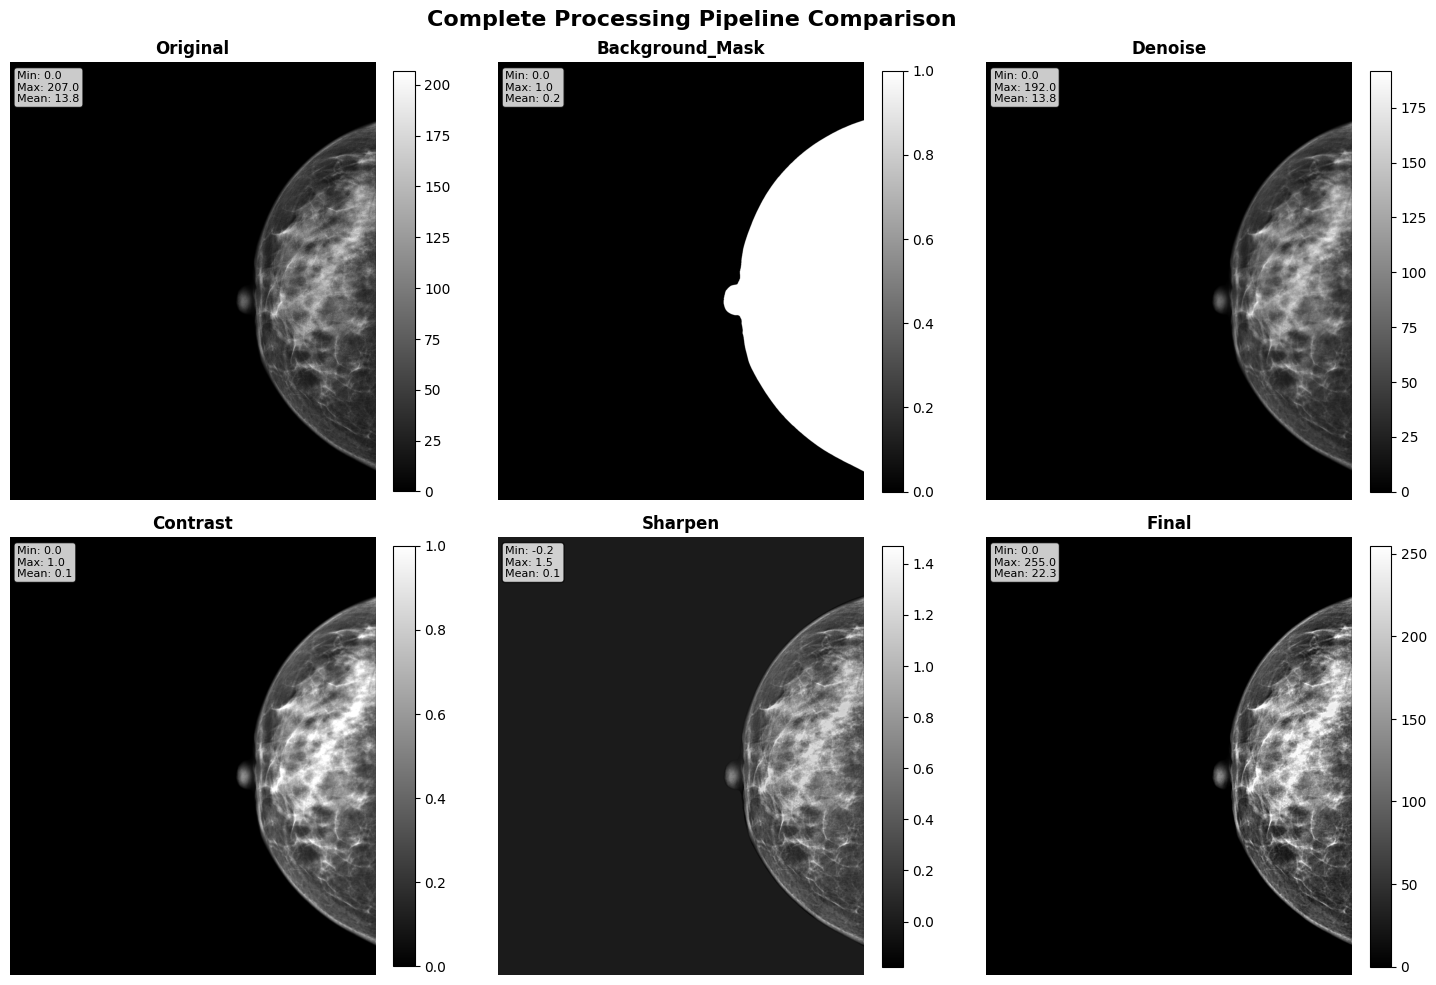


Processing Pipeline Summary:
1. Original
   Shape: (2294, 1914)
   Intensity range: [0.00, 207.00]
   Mean ± Std: 13.81 ± 30.92

2. Background_Mask
   Shape: (2294, 1914)
   Intensity range: [0.00, 1.00]
   Mean ± Std: 0.20 ± 0.40
   Contrast change: -98.7%

3. Denoise
   Shape: (2294, 1914)
   Intensity range: [0.00, 192.00]
   Mean ± Std: 13.75 ± 30.58
   Contrast change: -1.1%

4. Contrast
   Shape: (2294, 1914)
   Intensity range: [0.00, 1.00]
   Mean ± Std: 0.09 ± 0.21
   Contrast change: -99.3%

5. Sharpen
   Shape: (2294, 1914)
   Intensity range: [-0.18, 1.47]
   Mean ± Std: 0.11 ± 0.24
   Contrast change: -99.2%

6. Final
   Shape: (2294, 1914)
   Intensity range: [0.00, 255.00]
   Mean ± Std: 22.29 ± 50.59
   Contrast change: +63.6%



In [10]:
# === SIDE-BY-SIDE COMPARISON OF ALL PROCESSING STEPS ===

def create_processing_pipeline_comparison():
    """Create a side-by-side comparison of all processing steps."""
    
    # Load all images
    original = sitk.GetArrayFromImage(img_in)
    processing_steps = ['original'] + list(outputs.keys())
    
    # Handle 3D images (take middle slice)
    if original.ndim == 3:
        slice_idx = original.shape[0] // 2
        images = {'original': original[slice_idx]}
        for step_name, filepath in outputs.items():
            img = sitk.ReadImage(filepath)
            img_array = sitk.GetArrayFromImage(img)
            images[step_name] = img_array[slice_idx] if img_array.ndim == 3 else img_array
    else:
        images = {'original': original}
        for step_name, filepath in outputs.items():
            img = sitk.ReadImage(filepath)
            images[step_name] = sitk.GetArrayFromImage(img)
    
    # Create figure
    n_steps = len(processing_steps)
    cols = min(3, n_steps)  # Max 3 columns
    rows = (n_steps + cols - 1) // cols  # Calculate rows needed
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    fig.suptitle('Complete Processing Pipeline Comparison', fontsize=16, fontweight='bold')
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(1, -1) if n_steps > 1 else [axes]
    
    # Plot each step
    for i, step_name in enumerate(processing_steps):
        row = i // cols
        col = i % cols
        
        if rows > 1:
            ax = axes[row, col]
        else:
            ax = axes[col] if n_steps > 1 else axes
            
        img_data = images[step_name]
        
        im = ax.imshow(img_data, cmap='gray', origin='upper')
        ax.set_title(f'{step_name.title()}', fontweight='bold')
        ax.axis('off')
        
        # Add colorbar for intensity reference
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # Add statistics
        stats_text = f"Min: {img_data.min():.1f}\nMax: {img_data.max():.1f}\nMean: {img_data.mean():.1f}"
        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=8,
               verticalalignment='top', bbox=props)
    
    # Hide empty subplots
    for i in range(n_steps, rows * cols):
        row = i // cols
        col = i % cols
        if rows > 1:
            axes[row, col].set_visible(False)
        elif n_steps > 1:
            axes[col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Print processing summary
    print("\nProcessing Pipeline Summary:")
    print("=" * 40)
    for i, step_name in enumerate(processing_steps):
        img_data = images[step_name]
        print(f"{i+1}. {step_name.title()}")
        print(f"   Shape: {img_data.shape}")
        print(f"   Intensity range: [{img_data.min():.2f}, {img_data.max():.2f}]")
        print(f"   Mean ± Std: {img_data.mean():.2f} ± {img_data.std():.2f}")
        if i > 0:  # Compare with original
            orig_data = images['original']
            contrast_improvement = (img_data.std() / orig_data.std() - 1) * 100
            print(f"   Contrast change: {contrast_improvement:+.1f}%")
        print()

# Run the pipeline comparison
create_processing_pipeline_comparison()

Running Difference Analysis...


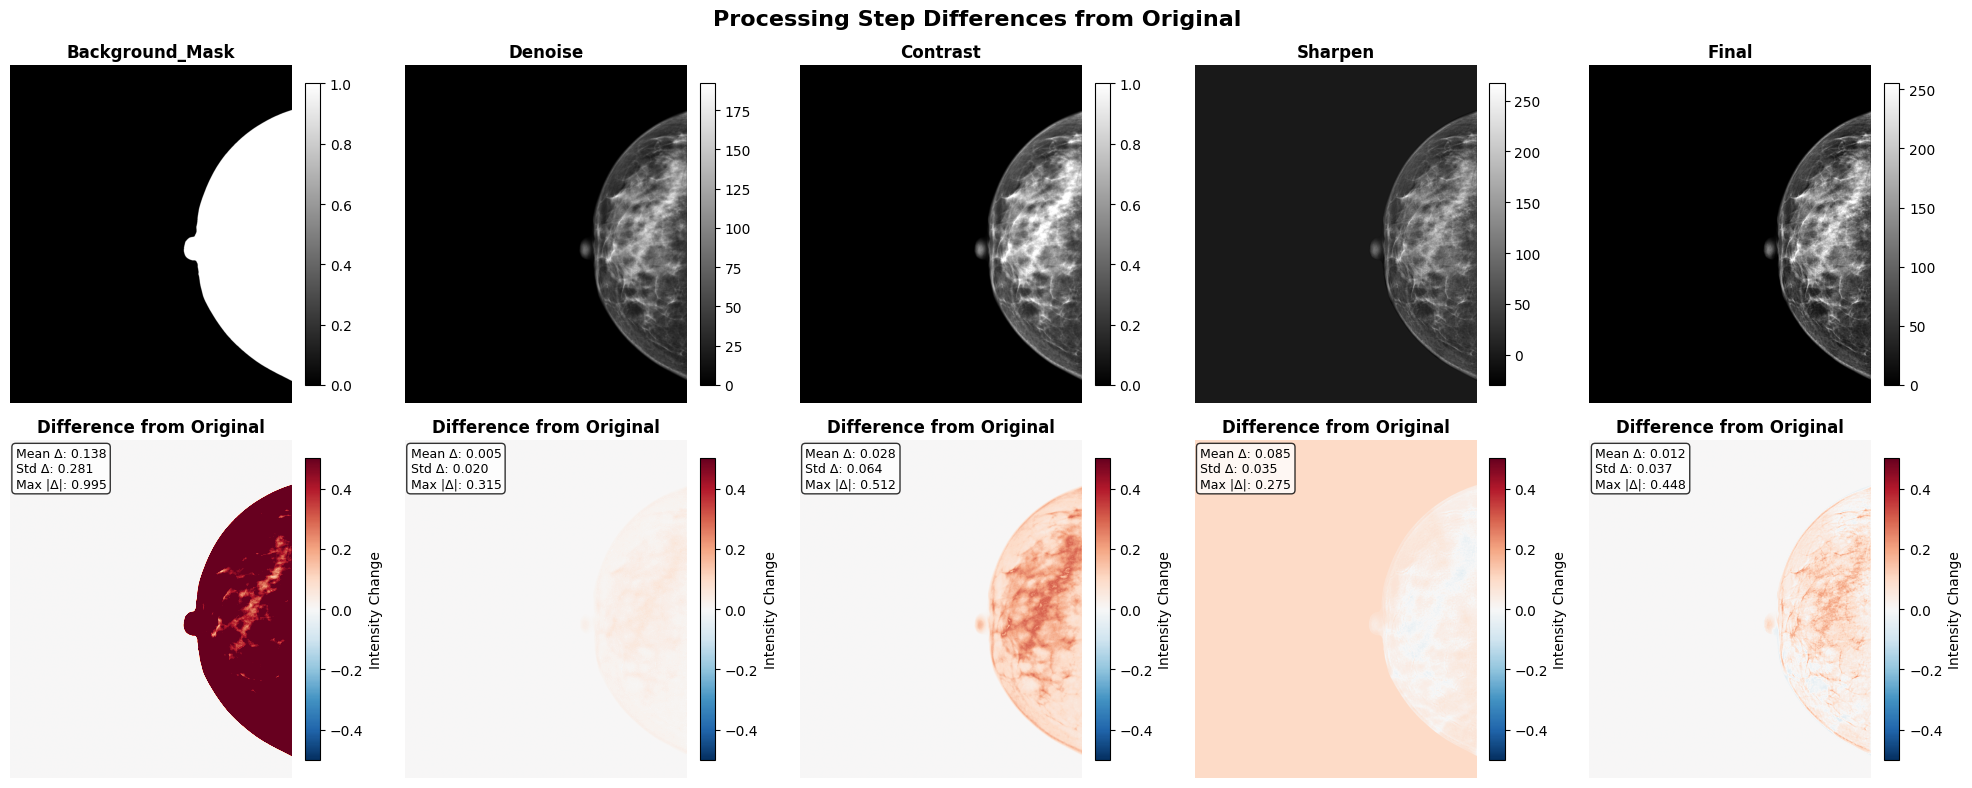


Difference Analysis Summary:
Background_Mask:
  Mean intensity change: +0.1376
  Std of changes: 0.2805
  Max absolute change: 0.9952
  % pixels changed > 0.1: 20.4%
  % pixels brightened: 20.4%
  % pixels darkened: 0.0%

Denoise:
  Mean intensity change: +0.0049
  Std of changes: 0.0199
  Max absolute change: 0.3147
  % pixels changed > 0.1: 0.8%
  % pixels brightened: 15.9%
  % pixels darkened: 4.6%

Contrast:
  Mean intensity change: +0.0279
  Std of changes: 0.0640
  Max absolute change: 0.5122
  % pixels changed > 0.1: 13.0%
  % pixels brightened: 20.4%
  % pixels darkened: 0.0%

Sharpen:
  Mean intensity change: +0.0852
  Std of changes: 0.0353
  Max absolute change: 0.2754
  % pixels changed > 0.1: 80.3%
  % pixels brightened: 95.3%
  % pixels darkened: 4.7%

Final:
  Mean intensity change: +0.0120
  Std of changes: 0.0366
  Max absolute change: 0.4477
  % pixels changed > 0.1: 4.6%
  % pixels brightened: 17.2%
  % pixels darkened: 3.3%


Creating Interactive Zoom Comparison...

interactive(children=(Dropdown(description='Compare with:', index=4, options=('background_mask', 'denoise', 'c…

In [13]:
# === DIFFERENCE ANALYSIS VISUALIZATION ===

def create_difference_analysis():
    """Create visualizations showing the differences between processing steps."""
    
    # Load all images
    original = sitk.GetArrayFromImage(img_in)
    
    # Handle 3D images (take middle slice)
    if original.ndim == 3:
        slice_idx = original.shape[0] // 2
        images = {'original': original[slice_idx]}
        for step_name, filepath in outputs.items():
            img = sitk.ReadImage(filepath)
            img_array = sitk.GetArrayFromImage(img)
            images[step_name] = img_array[slice_idx] if img_array.ndim == 3 else img_array
    else:
        images = {'original': original}
        for step_name, filepath in outputs.items():
            img = sitk.ReadImage(filepath)
            images[step_name] = sitk.GetArrayFromImage(img)
    
    # Create difference maps
    step_names = list(outputs.keys())
    n_steps = len(step_names)
    
    fig, axes = plt.subplots(2, n_steps, figsize=(4*n_steps, 8))
    fig.suptitle('Processing Step Differences from Original', fontsize=16, fontweight='bold')
    
    # Handle case where there's only one step
    if n_steps == 1:
        axes = axes.reshape(-1, 1)
    
    for i, step_name in enumerate(step_names):
        processed_img = images[step_name]
        original_img = images['original']
        
        # Normalize both images to same range for fair comparison
        orig_norm = (original_img - original_img.min()) / (original_img.max() - original_img.min())
        proc_norm = (processed_img - processed_img.min()) / (processed_img.max() - processed_img.min())
        
        # Calculate difference
        difference = proc_norm - orig_norm
        
        # Plot processed image
        im1 = axes[0, i].imshow(processed_img, cmap='gray', origin='upper')
        axes[0, i].set_title(f'{step_name.title()}', fontweight='bold')
        axes[0, i].axis('off')
        plt.colorbar(im1, ax=axes[0, i], fraction=0.046, pad=0.04)
        
        # Plot difference map
        im2 = axes[1, i].imshow(difference, cmap='RdBu_r', origin='upper', vmin=-0.5, vmax=0.5)
        axes[1, i].set_title(f'Difference from Original', fontweight='bold')
        axes[1, i].axis('off')
        plt.colorbar(im2, ax=axes[1, i], fraction=0.046, pad=0.04, label='Intensity Change')
        
        # Add statistics
        stats_text = f"Mean Δ: {difference.mean():.3f}\nStd Δ: {difference.std():.3f}\nMax |Δ|: {np.abs(difference).max():.3f}"
        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        axes[1, i].text(0.02, 0.98, stats_text, transform=axes[1, i].transAxes, fontsize=9,
                       verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()
    
    # Print difference analysis
    print("\nDifference Analysis Summary:")
    print("=" * 50)
    for step_name in step_names:
        processed_img = images[step_name]
        original_img = images['original']
        
        # Normalize for comparison
        orig_norm = (original_img - original_img.min()) / (original_img.max() - original_img.min())
        proc_norm = (processed_img - processed_img.min()) / (processed_img.max() - processed_img.min())
        difference = proc_norm - orig_norm
        
        print(f"{step_name.title()}:")
        print(f"  Mean intensity change: {difference.mean():+.4f}")
        print(f"  Std of changes: {difference.std():.4f}")
        print(f"  Max absolute change: {np.abs(difference).max():.4f}")
        print(f"  % pixels changed > 0.1: {(np.abs(difference) > 0.1).mean()*100:.1f}%")
        print(f"  % pixels brightened: {(difference > 0).mean()*100:.1f}%")
        print(f"  % pixels darkened: {(difference < 0).mean()*100:.1f}%")
        print()

# Interactive zoom comparison for specific regions
def create_interactive_zoom_comparison():
    """Create an interactive tool to compare zoomed regions between original and any processing step."""
    
    # Load images
    original = sitk.GetArrayFromImage(img_in)
    if original.ndim == 3:
        original = original[original.shape[0] // 2]
    
    step_dropdown = widgets.Dropdown(
        options=list(outputs.keys()),
        value=list(outputs.keys())[-1],
        description='Compare with:',
        style={'description_width': 'initial'}
    )
    
    zoom_size_slider = widgets.IntSlider(
        value=100,
        min=50,
        max=300,
        step=10,
        description='Zoom Size:',
        style={'description_width': 'initial'}
    )
    
    def update_zoom_comparison(step_name, zoom_size):
        # Load processed image
        img = sitk.ReadImage(outputs[step_name])
        processed = sitk.GetArrayFromImage(img)
        if processed.ndim == 3:
            processed = processed[processed.shape[0] // 2]
        
        # Create clickable comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        fig.suptitle(f'Click anywhere to zoom in - Original vs {step_name.title()}', fontsize=14)
        
        # Display full images
        ax1.imshow(original, cmap='gray', origin='upper')
        ax1.set_title('Original (Click to zoom)')
        ax1.axis('off')
        
        ax2.imshow(processed, cmap='gray', origin='upper')
        ax2.set_title(f'{step_name.title()} (Click to zoom)')
        ax2.axis('off')
        
        # Store zoom windows for updates
        zoom_windows = {'ax1': None, 'ax2': None}
        
        def on_click(event):
            if event.inaxes in [ax1, ax2]:
                x, y = int(event.xdata), int(event.ydata)
                half_size = zoom_size // 2
                
                # Calculate zoom bounds
                y1, y2 = max(0, y - half_size), min(original.shape[0], y + half_size)
                x1, x2 = max(0, x - half_size), min(original.shape[1], x + half_size)
                
                # Clear previous zoom windows
                if zoom_windows['ax1']:
                    zoom_windows['ax1'].remove()
                if zoom_windows['ax2']:
                    zoom_windows['ax2'].remove()
                
                # Create zoom windows
                zoom_orig = original[y1:y2, x1:x2]
                zoom_proc = processed[y1:y2, x1:x2]
                
                # Create new figure for zoom comparison
                zoom_fig, (zax1, zax2) = plt.subplots(1, 2, figsize=(10, 5))
                zoom_fig.suptitle(f'Zoomed Comparison at ({x}, {y})', fontsize=14)
                
                zax1.imshow(zoom_orig, cmap='gray', origin='upper')
                zax1.set_title(f'Original\nMean: {zoom_orig.mean():.1f}, Std: {zoom_orig.std():.1f}')
                zax1.axis('off')
                
                zax2.imshow(zoom_proc, cmap='gray', origin='upper')
                zax2.set_title(f'{step_name.title()}\nMean: {zoom_proc.mean():.1f}, Std: {zoom_proc.std():.1f}')
                zax2.axis('off')
                
                plt.tight_layout()
                plt.show()
        
        fig.canvas.mpl_connect('button_press_event', on_click)
        plt.show()
    
    interactive_zoom = widgets.interactive(
        update_zoom_comparison,
        step_name=step_dropdown,
        zoom_size=zoom_size_slider
    )
    
    display(interactive_zoom)

print("Running Difference Analysis...")
create_difference_analysis()

print("\nCreating Interactive Zoom Comparison...")
create_interactive_zoom_comparison()